In [ ]:
import pandas as pd

data = pd.read_csv('output/wucaishen_enriched_output_2401.csv')
data.head()


In [ ]:
data.columns.tolist()

In [ ]:
import glob
from bituslabs_ds.eda import read_csv_cols

files = glob.glob(f'./output/wucaishen_enriched_output_24??.csv')
print(files)
sampling = 2_000_000
data = read_csv_cols(
    files,
    columns = ['group_id', 'billtime', 'basepoint', 'account', 'cus_account', 'payout', 'delta_t', 'delta_bet', 'delta_profit', 'delta_payout','streak', 'win_streak', 'lose_streak', 'rtp'],
    filters={'currency': 'CNY'},
    sampling=sampling
)

data['billtime'] = pd.to_datetime(data['billtime'])
data['bill_day'] = data['billtime'].dt.date
data = data.drop(columns='billtime').groupby(['group_id', 'bill_day']).mean().reset_index()
data.drop(columns='group_id').to_csv(f'./output/wucaishen_enriched_output_24_group_mean_{sampling}.csv', index=False)

In [3]:
import pandas as pd
data = pd.read_csv('./output/wucaishen_enriched_output_24_group_mean_2000000.csv')

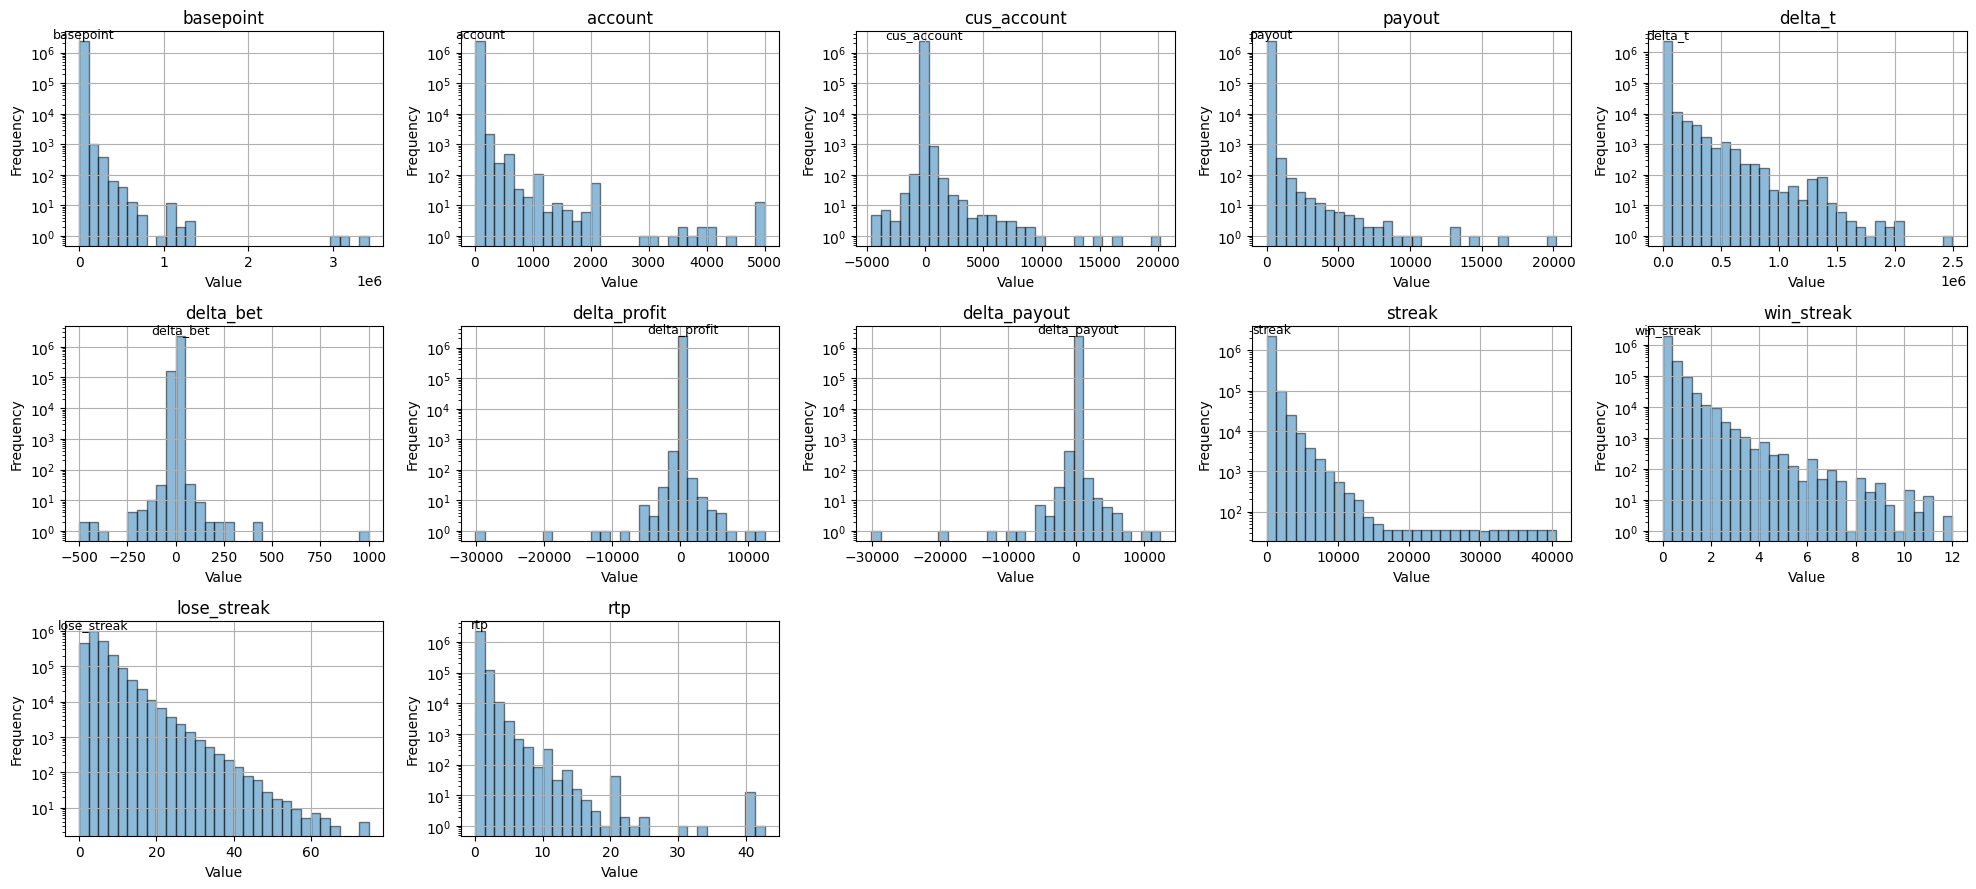

In [40]:

from bituslabs_ds.eda import plot_df_distribution
plot_df_distribution(data.iloc[:, 1:], log=True)


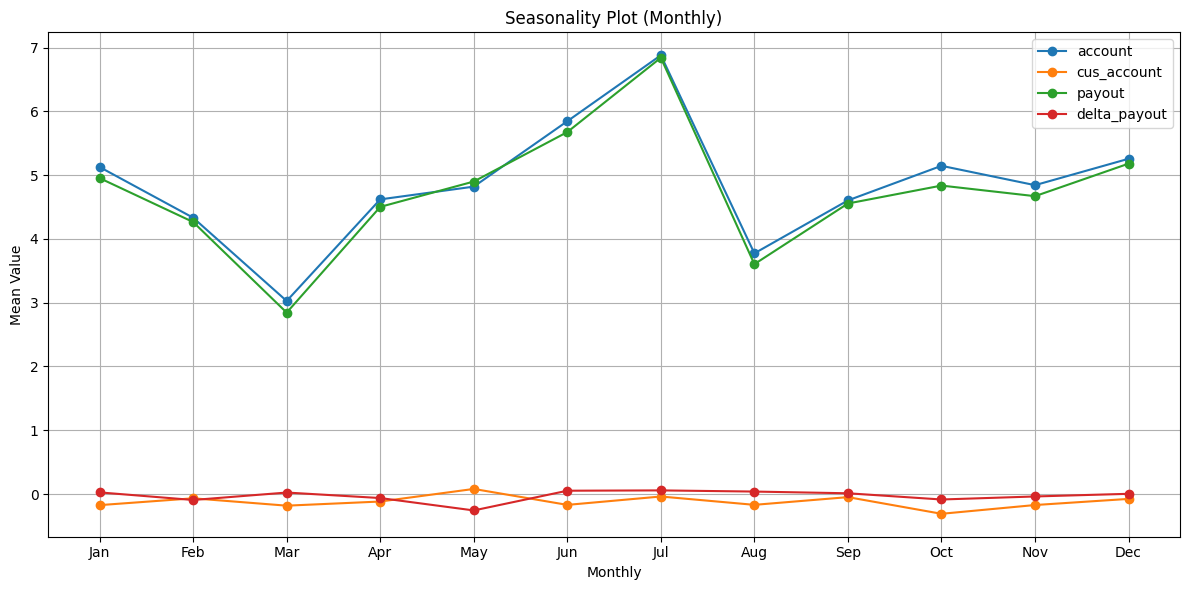

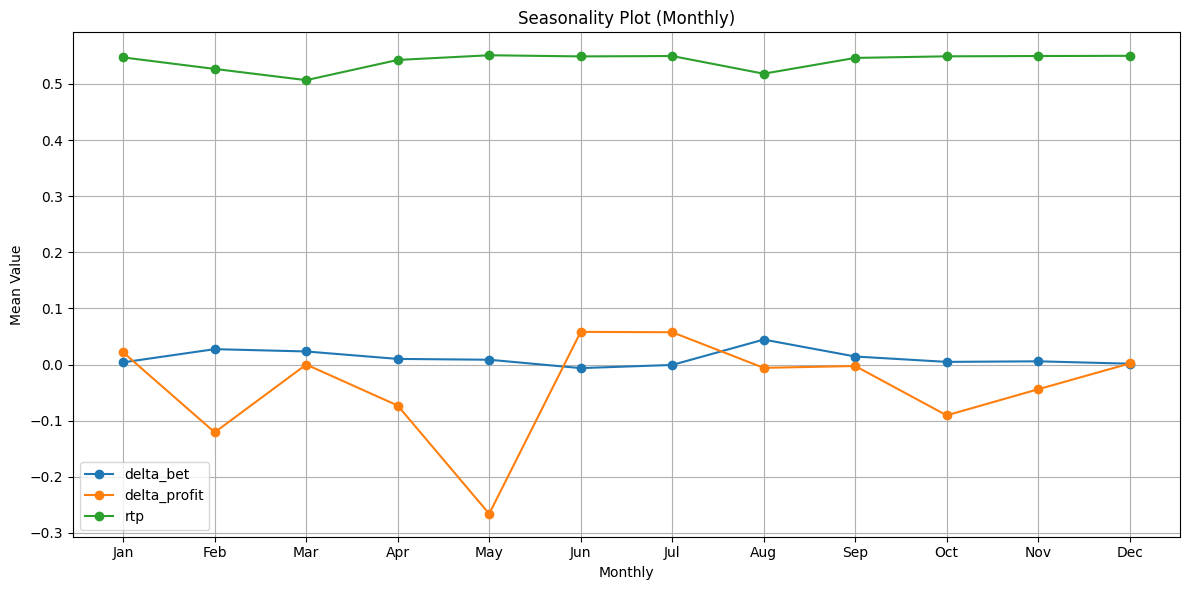

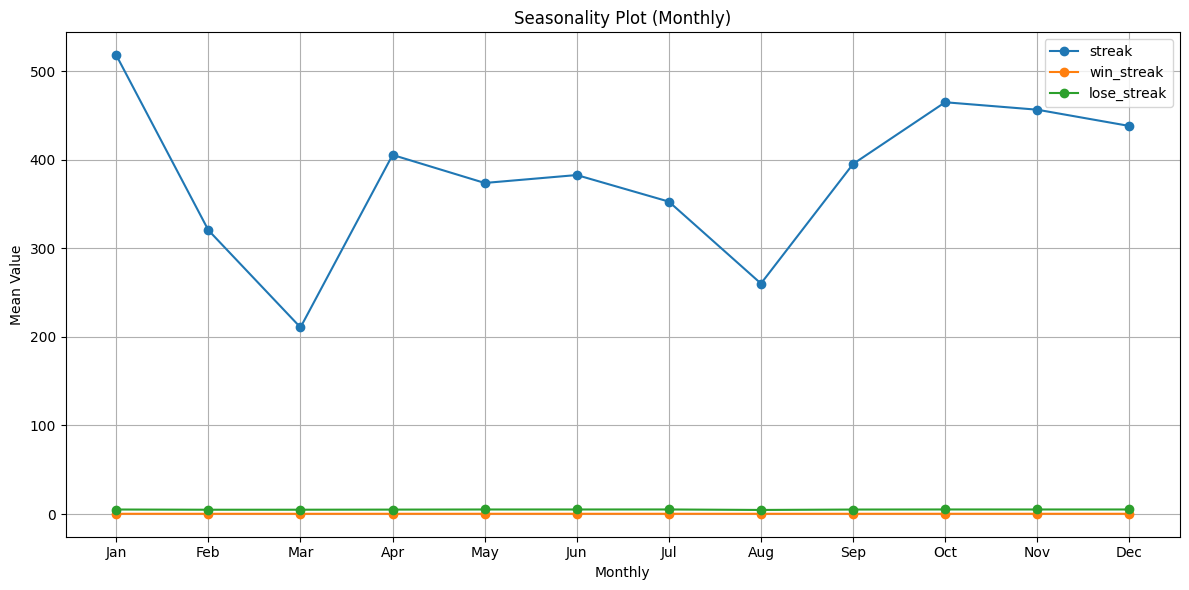

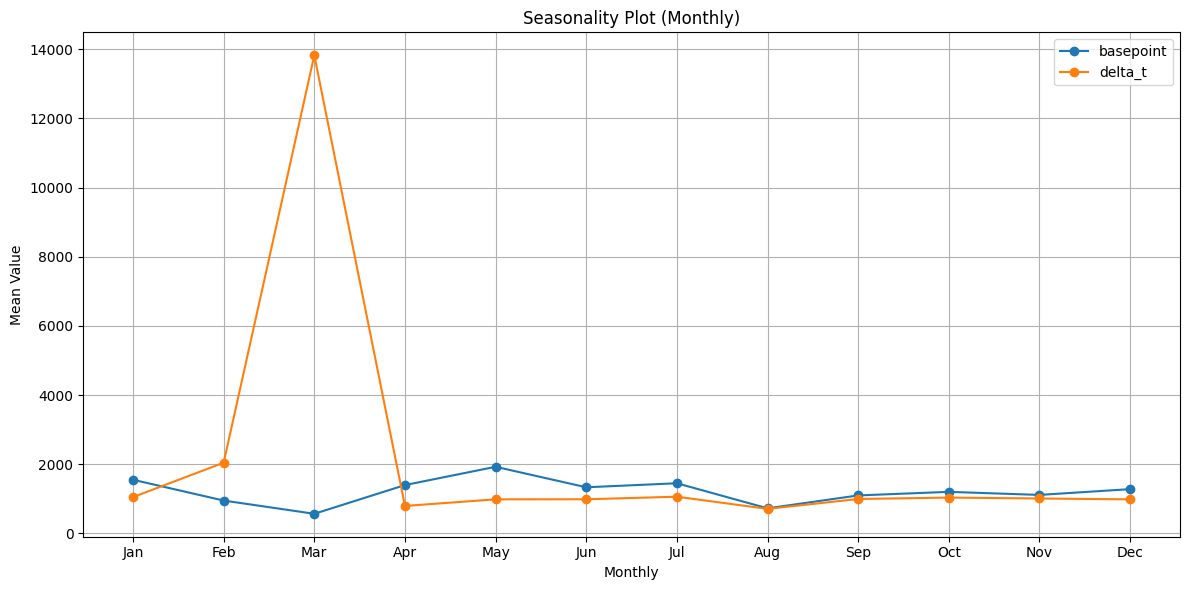

In [5]:

from bituslabs_ds.eda import plot_seasonality

plot_seasonality(data['bill_day'], data[['account', 'cus_account', 'payout', 'delta_payout']])
plot_seasonality(data['bill_day'], data[['delta_bet', 'delta_profit', 'rtp']])
plot_seasonality(data['bill_day'], data[['streak', 'win_streak', 'lose_streak']])
plot_seasonality(data['bill_day'], data[['basepoint', 'delta_t']])

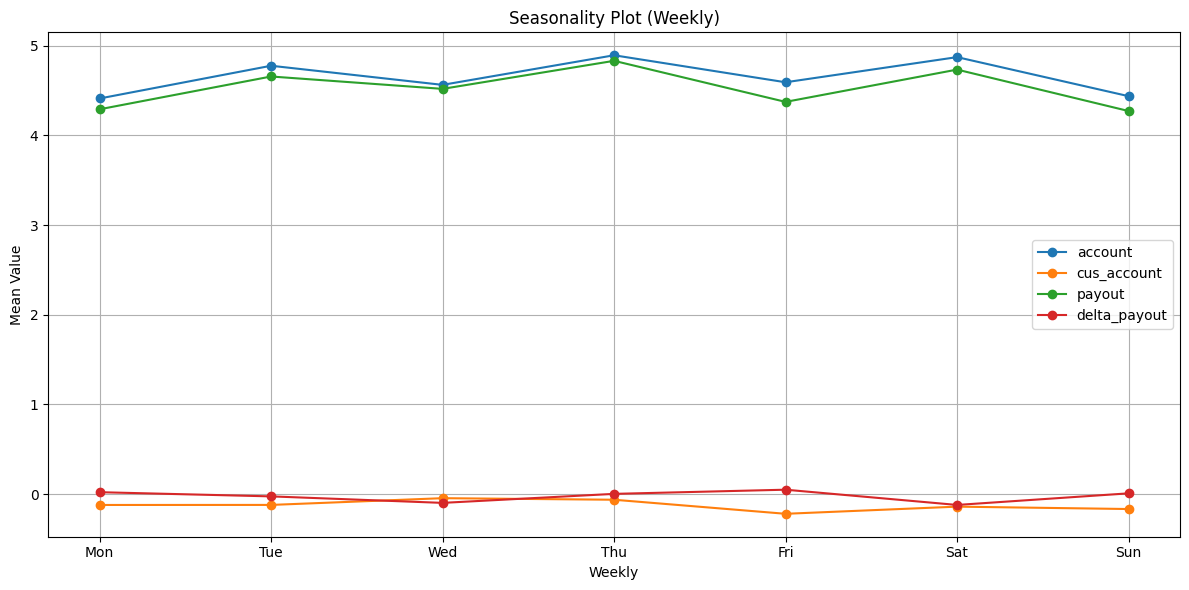

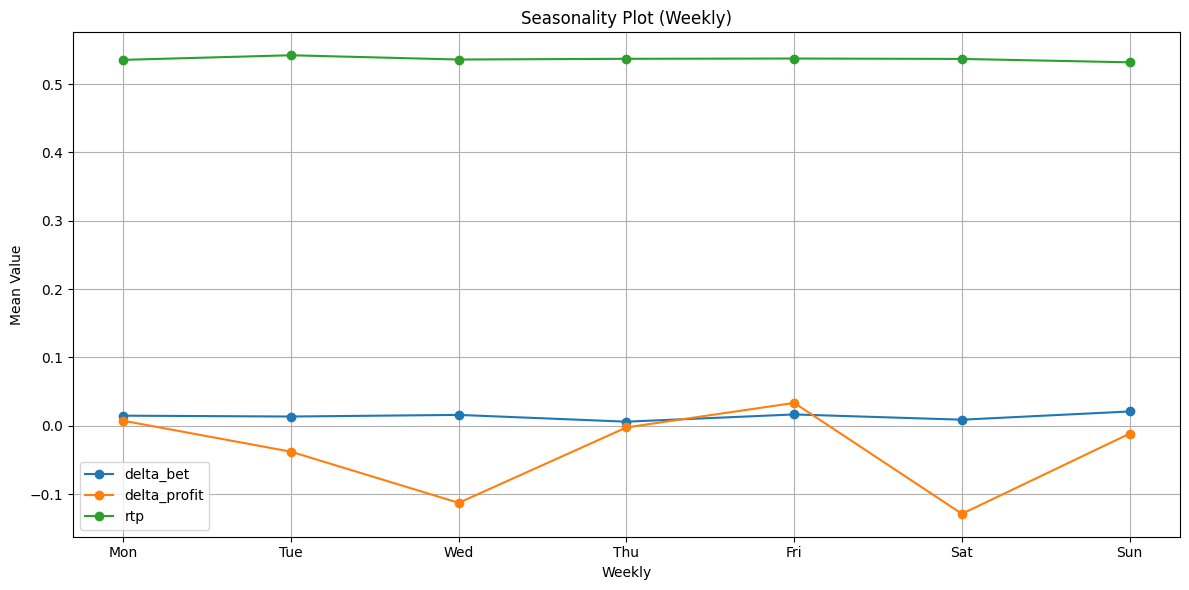

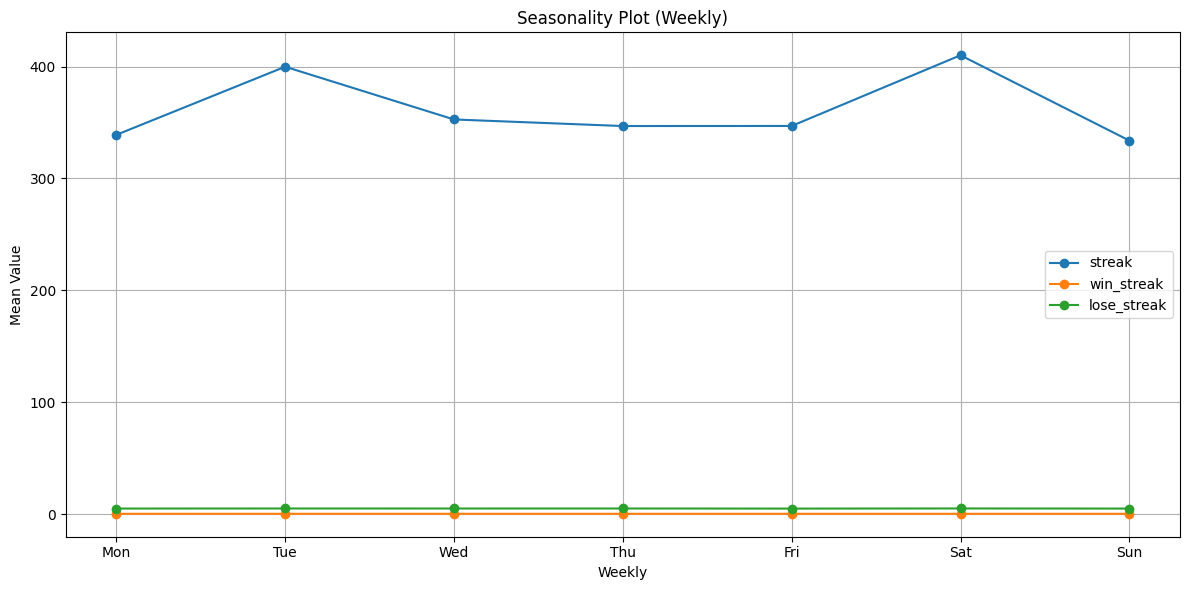

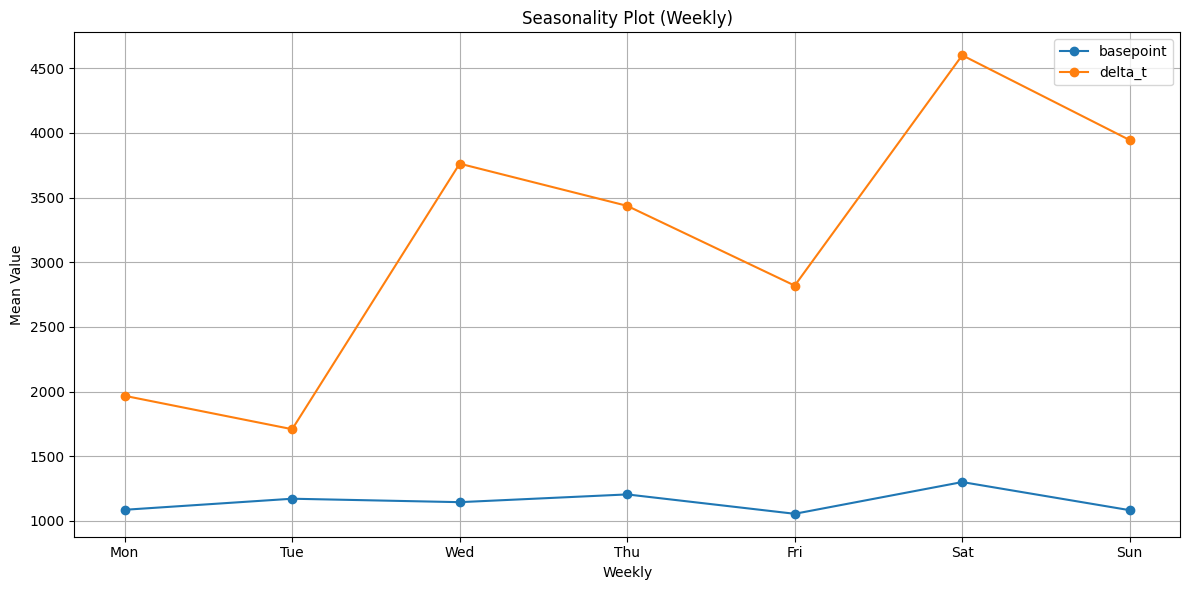

In [6]:

plot_seasonality(data['bill_day'], data[['account', 'cus_account', 'payout', 'delta_payout']], freq='weekly')
plot_seasonality(data['bill_day'], data[['delta_bet', 'delta_profit', 'rtp']], freq='weekly')
plot_seasonality(data['bill_day'], data[['streak', 'win_streak', 'lose_streak']], freq='weekly')
plot_seasonality(data['bill_day'], data[['basepoint', 'delta_t']], freq='weekly')

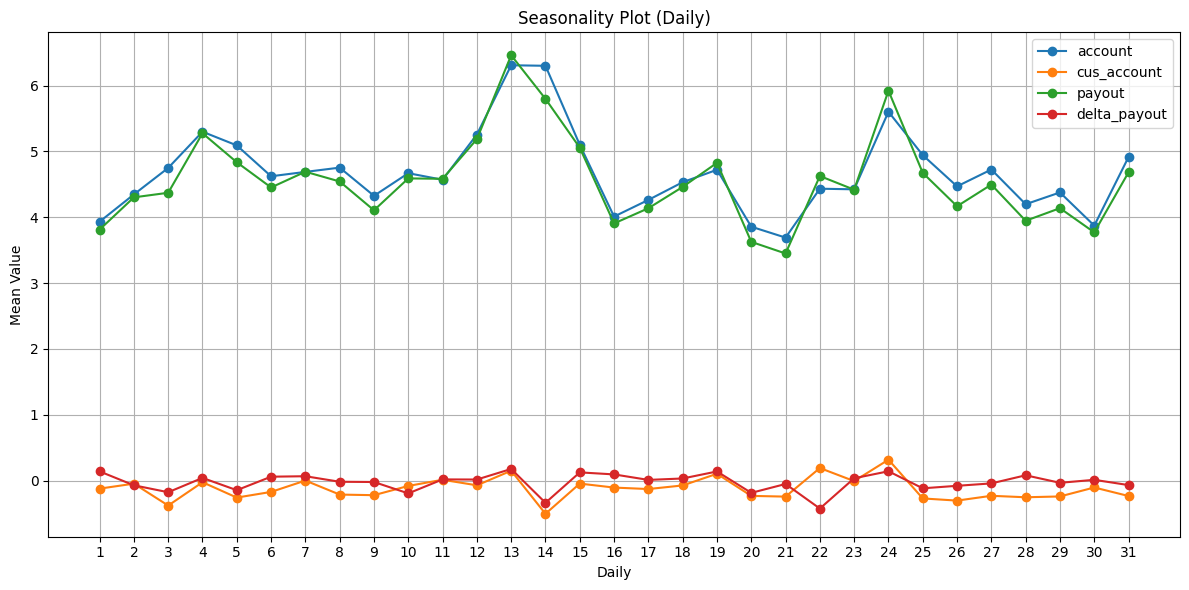

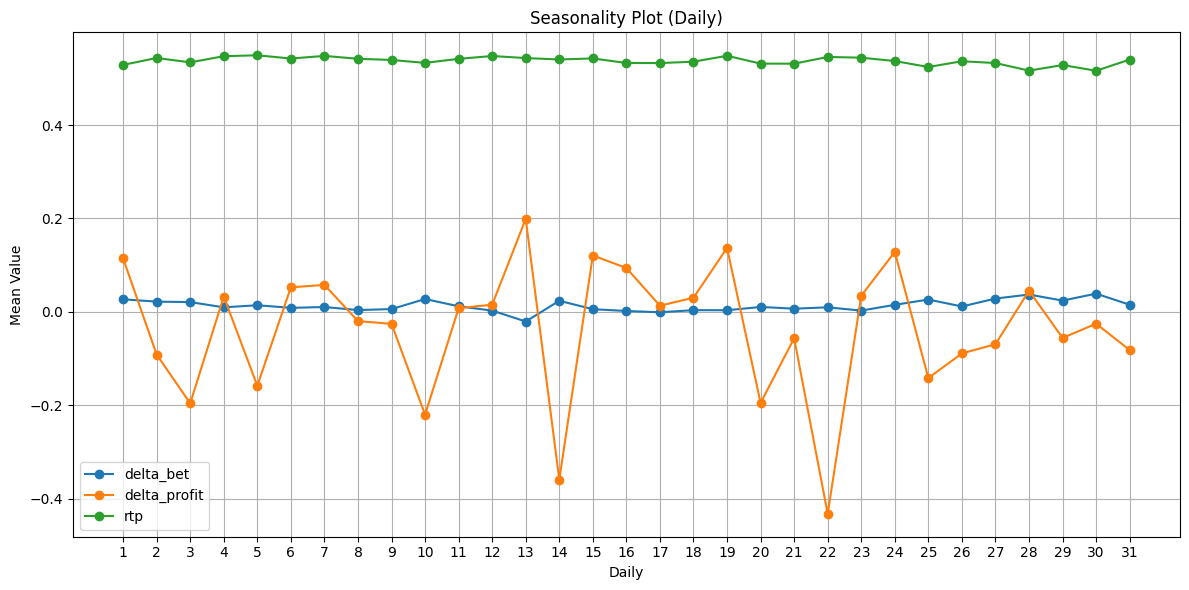

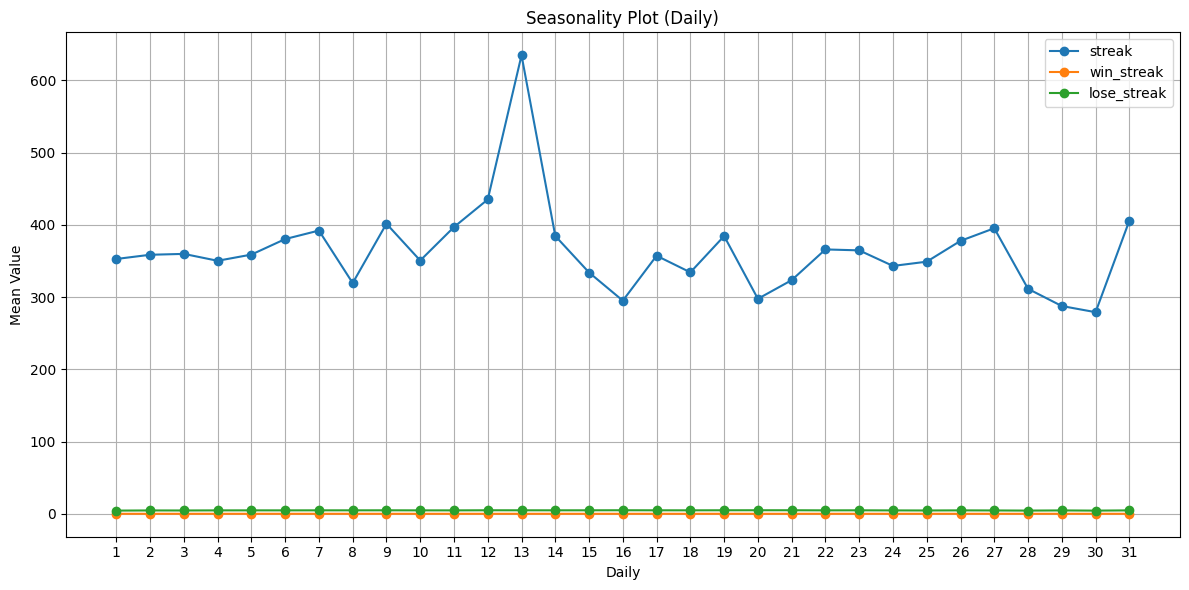

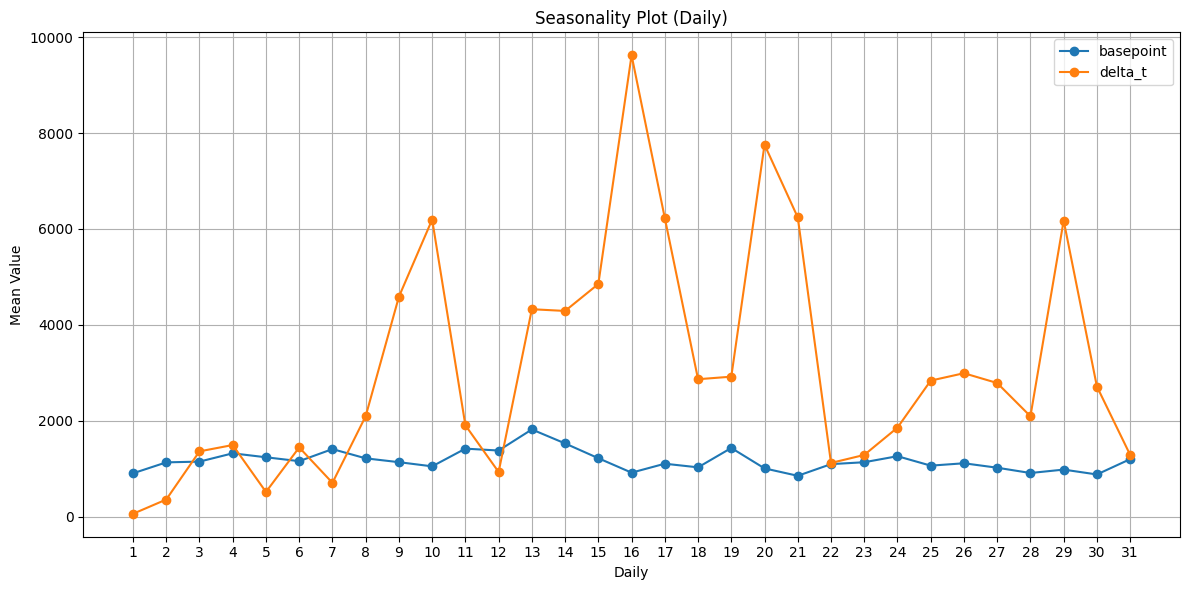

In [8]:
plot_seasonality(data['bill_day'], data[['account', 'cus_account', 'payout', 'delta_payout']], freq='daily')
plot_seasonality(data['bill_day'], data[['delta_bet', 'delta_profit', 'rtp']], freq='daily')
plot_seasonality(data['bill_day'], data[['streak', 'win_streak', 'lose_streak']], freq='daily')
plot_seasonality(data['bill_day'], data[['basepoint', 'delta_t']], freq='daily')

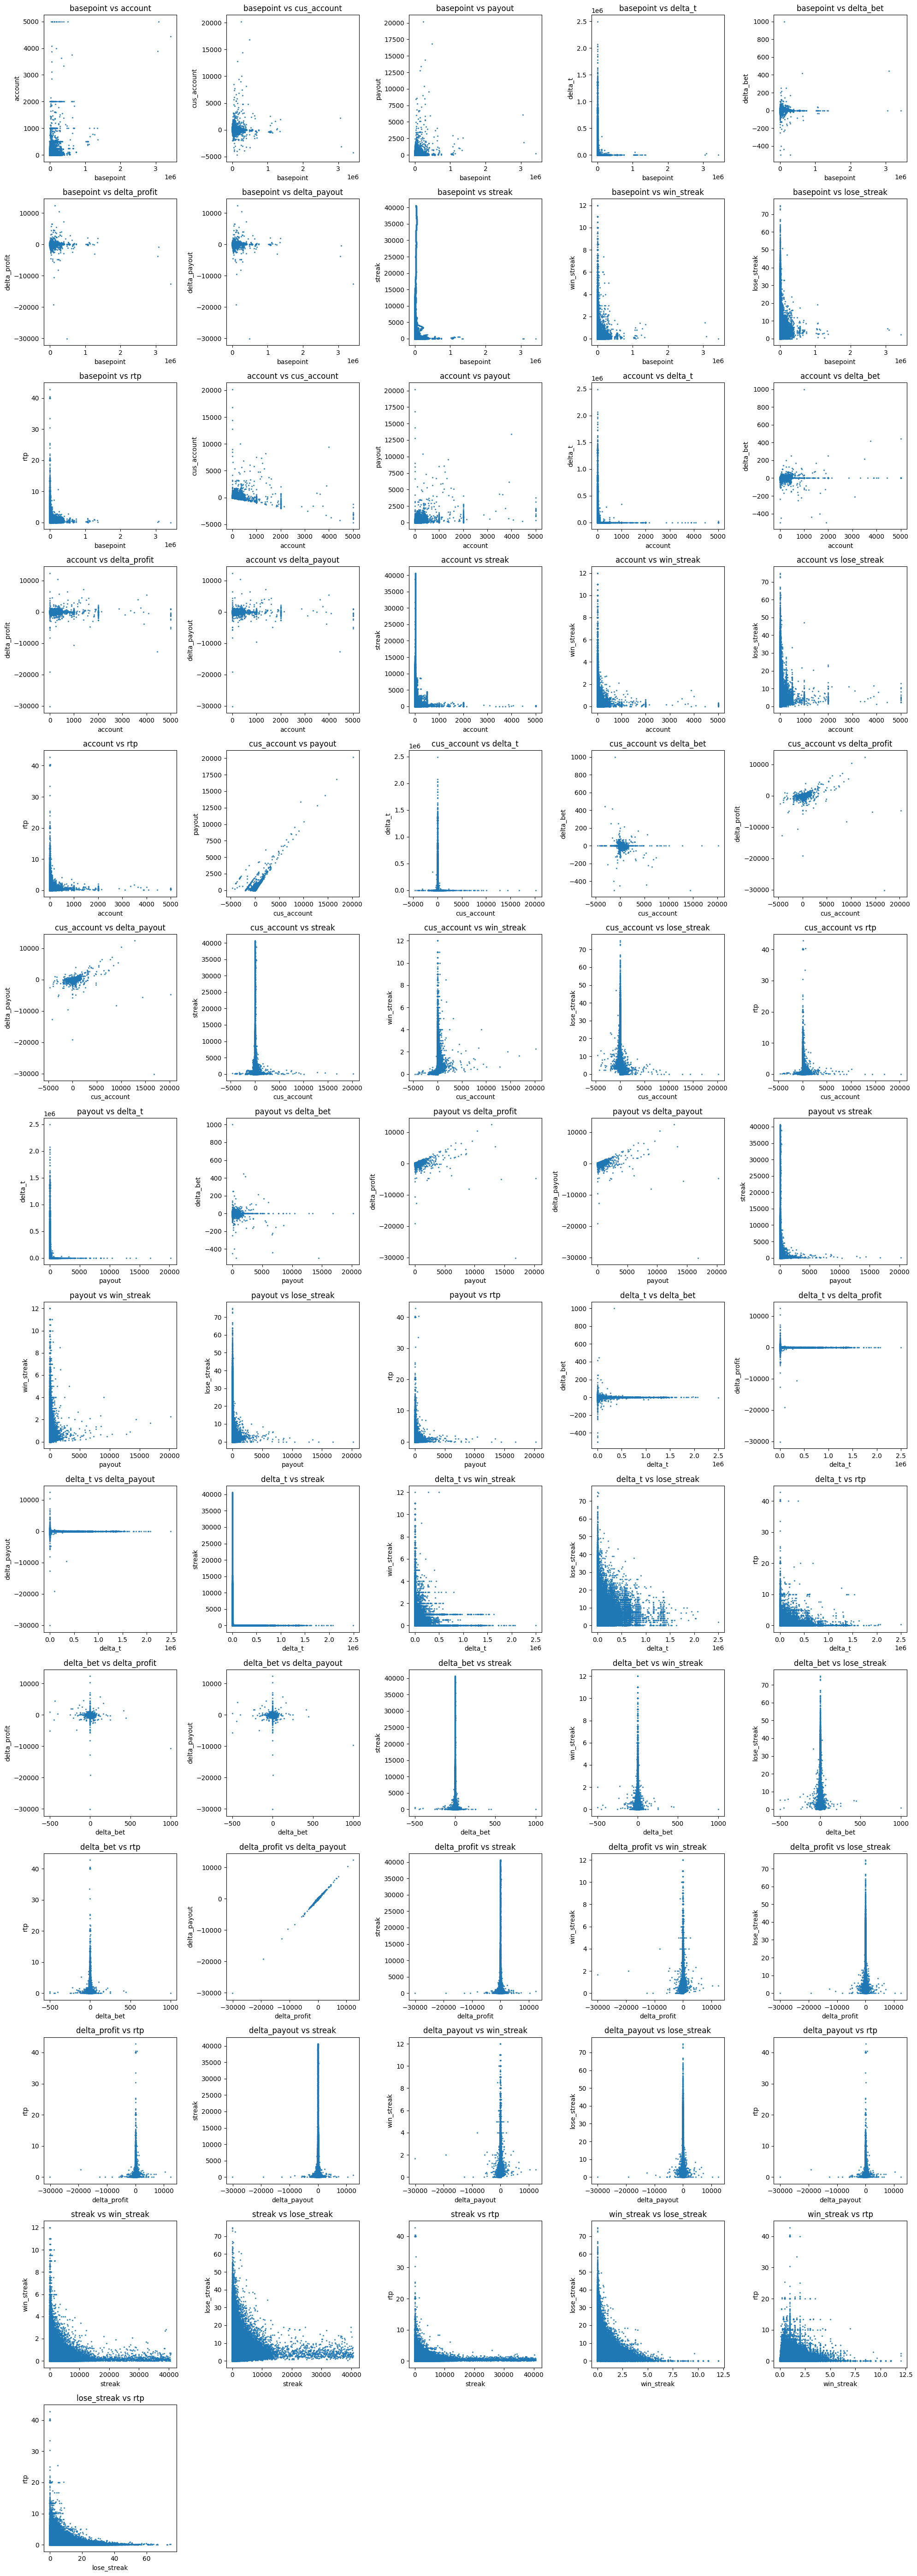

In [7]:
from bituslabs_ds.eda import plot_scatter_pairs

plot_scatter_pairs(data.iloc[:, 1:])